<a id="toc"></a>
# **Predicting Irrigation Need: LightGBM**

Table of Contents:
- [About the Project](#1)
- [About the Data](#2)
- [Set Up](#3)
- [Exploratory Data Analysis](#4)
    - [Training Data Overview](#4.1)
    - [Testing Data Overview](#4.2)
    - [Target Variable: Irrigation Need](#4.3)
    - [Numerical Features](#4.4)
    - [Categorical Features](#4.5)
    - [Feature Interactions](#4.6)
- [Adversarial Validation](#5)
- [Data Cleaning & Preprocessing](#6)
    - [Combining the Data](#6.1)
    - [Feature Engineering](#6.2)
    - [Encoding](#6.3)
- [Modeling: LightGBM](#7)
    - [Baseline Model](#7.1)
    - [Optimizing with Optuna](#7.2)
- [Training & Evaluation](#8)
- [Predictions & Submission](#9)
- [Discussion](#10)
- [References](#ref)

<a id="toc"></a>  <a href="#2" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="1"></a>
# **1) About the Project**

This project has been completed as part of [Kaggle's Predicting Irrigation Need Competition](https://www.kaggle.com/competitions/playground-series-s6e4).

**Objective:** Predict the irrigation need - classified as **Low**, **Medium**, or **High** - for a given agricultural field based on a set of soil, weather, crop, and field management features. This is a **multi-class classification** problem.

**Model:** We will build a **LightGBM** (Light Gradient Boosting Machine) classifier. LightGBM is a highly efficient, tree-based ensemble method known for its speed and performance on large datasets. Unlike XGBoost, LightGBM uses a leaf-wise growth strategy and histogram-based splitting, which allows it to scale gracefully to hundreds of thousands of samples, making it a natural fit for this competition. Additionally, LightGBM supports native categorical feature handling, which is advantageous given the number of categorical columns in this dataset.

**Evaluation Metric:** Submissions are evaluated using **Balanced Accuracy**, which computes accuracy for each class independently and then averages those per-class rates. Unlike standard accuracy, balanced accuracy gives equal weight to all three classes regardless of their frequency in the dataset, making it well-suited for the imbalanced distribution observed here.

<a id="toc"></a>  <a href="#1" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#3" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="2"></a>
# **2) About the Data**

The datasets provided in this competition were generated from a deep learning model trained on the original [Irrigation Prediction dataset](https://www.kaggle.com/datasets/nelakurthisudheer/irrigation-prediction) available on Kaggle. While the data is synthetically generated, it closely mimics the statistical properties of the source material.

Three datasets are used throughout this project:
- **Train (`train.csv`)**: 630,000 rows; 19 feature columns + 1 target column (`Irrigation_Need`)
- **Test (`test.csv`)**: 270,000 rows; 19 feature columns (no target)
- **Original (`irrigation_prediction.csv`)**: 10,000 rows; real-world data used as a supplement

**Feature Descriptions:**

| Feature | Type | Description |
|---|---|---|
| `Soil_Type` | Categorical | Type of soil (Loamy, Clay, Sandy, Silt) |
| `Soil_pH` | Numerical | pH level of the soil (4.8 - 8.2) |
| `Soil_Moisture` | Numerical | Volumetric soil moisture (%) |
| `Organic_Carbon` | Numerical | Organic carbon content of soil (%) |
| `Electrical_Conductivity` | Numerical | Soil salinity proxy (dS/m) |
| `Temperature_C` | Numerical | Ambient temperature (°C) |
| `Humidity` | Numerical | Relative humidity (%) |
| `Rainfall_mm` | Numerical | Annual rainfall (mm) |
| `Sunlight_Hours` | Numerical | Daily sunlight hours |
| `Wind_Speed_kmh` | Numerical | Wind speed (km/h) |
| `Crop_Type` | Categorical | Type of crop (Sugarcane, Wheat, Rice, etc.) |
| `Crop_Growth_Stage` | Categorical | Growth stage (Sowing, Vegetative, Flowering, Harvest) |
| `Season` | Categorical | Agricultural season (Rabi, Kharif, Zaid) |
| `Irrigation_Type` | Categorical | Irrigation method (Drip, Canal, Sprinkler, Rainfed) |
| `Water_Source` | Categorical | Source of water (River, Reservoir, Rainwater, Groundwater) |
| `Field_Area_hectare` | Numerical | Field area (hectares) |
| `Mulching_Used` | Categorical | Whether mulching was applied (Yes/No) |
| `Previous_Irrigation_mm` | Numerical | Amount of irrigation applied in previous cycle (mm) |
| `Region` | Categorical | Geographic region (North, South, East, West, Central) |

**Target Variable:** `Irrigation_Need` - one of three ordinal classes: **Low**, **Medium**, **High**

<a id="toc"></a>  <a href="#2" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#4" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="3"></a>
# **3) Set Up**

In [2]:
# Importing and loading necessary libraries and packages
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='white', palette='Set2')

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading in the datasets
df_train    = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
df_test     = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
df_original = pd.read_csv('/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv')

<a id="toc"></a>  <a href="#3" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#5" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="4"></a>
# **4) Exploratory Data Analysis**

<a id="toc"></a>
<a id="4.1"></a>
## **4.1) Training Data Overview**

In [3]:
# Viewing first 5 entries of 'df_train'
df_train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [5]:
# Creating a function to show a summary of a given dataset
def show_sum(df):
    sum_df = pd.DataFrame(index=list(df))
    sum_df['Dtype']    = df.dtypes
    sum_df['Count']    = df.count()
    sum_df['#Unique']  = df.nunique()
    sum_df['#Missing'] = df.isnull().sum()
    sum_df['%Missing'] = (df.isnull().sum() / len(df) * 100).round(2)
    return sum_df

In [6]:
# Examining summary of 'df_train'
show_sum(df_train)

,Dtype,Count,#Unique,#Missing,%Missing
id,int64,630000,630000,0,0.0
Soil_Type,object,630000,4,0,0.0
Soil_pH,float64,630000,341,0,0.0
Soil_Moisture,float64,630000,5223,0,0.0
Organic_Carbon,float64,630000,131,0,0.0
Electrical_Conductivity,float64,630000,341,0,0.0
Temperature_C,float64,630000,2934,0,0.0
Humidity,float64,630000,6475,0,0.0
Rainfall_mm,float64,630000,19308,0,0.0
Sunlight_Hours,float64,630000,701,0,0.0


In [7]:
# Examining summary statistics of each column in 'df_train'
df_train.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


**OBSERVATIONS: 'df_train'**
- Shape of the data:
    - 630,000 (rows), 21 (columns)
- Includes target variable `Irrigation_Need`
- Column types:
    - Float64 (8 numerical columns)
    - Int64 (1 column: `id`)
    - Object (8 categorical columns + 1 target column)
- No missing values across any column

**Summary Statistics: 'df_train'**

- **Soil_pH**: Mean: **6.48**; Range: 4.80 - 8.20 (slightly acidic to slightly alkaline)
- **Soil_Moisture**: Mean: **37.3%**; Range: 8.0 - 65.0 (wide variation, likely a strong predictor)
- **Organic_Carbon**: Mean: **0.92%**; Range: 0.30 - 1.60
- **Electrical_Conductivity**: Mean: **1.74 dS/m**; Range: 0.10 - 3.50
- **Temperature_C**: Mean: **27.0 degrees C**; Range: 12.0 - 42.0 (tropical to warm-temperate conditions)
- **Humidity**: Mean: **61.6%**; Range: 25.0 - 95.0
- **Rainfall_mm**: Mean: **1,462 mm**; Range: 0.38 - 2,500 (high variability)
- **Sunlight_Hours**: Mean: **7.5 hrs**; Range: 4.0 - 11.0
- **Wind_Speed_kmh**: Mean: **10.4 km/h**; Range: 0.5 - 20.0
- **Field_Area_hectare**: Mean: **7.5 ha**; Range: 0.3 - 15.0
- **Previous_Irrigation_mm**: Mean: **62.3 mm**; Range: 0.02 - 120.0

<a id="toc"></a>
<a id="4.2"></a>
## **4.2) Testing Data Overview**

In [8]:
# Viewing first 5 entries of 'df_test'
df_test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [10]:
# Examining summary of 'df_test'
show_sum(df_test)

,Dtype,Count,#Unique,#Missing,%Missing
id,int64,270000,270000,0,0.0
Soil_Type,object,270000,4,0,0.0
Soil_pH,float64,270000,341,0,0.0
Soil_Moisture,float64,270000,4963,0,0.0
Organic_Carbon,float64,270000,131,0,0.0
Electrical_Conductivity,float64,270000,341,0,0.0
Temperature_C,float64,270000,2864,0,0.0
Humidity,float64,270000,6149,0,0.0
Rainfall_mm,float64,270000,14483,0,0.0
Sunlight_Hours,float64,270000,700,0,0.0


In [11]:
# Examining summary statistics of each column in 'df_test'
df_test.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000
mean,764999.500000,6.480929,37.307614,0.922279,1.745251,27.001666,61.511319,1464.525885,7.513277,10.386531,7.508192,62.356021
std,77942.430678,0.922187,16.375273,0.365757,0.951329,8.630706,19.690278,612.521709,2.002661,5.683215,4.218736,34.225278
min,630000.000000,4.800000,8.010000,0.300000,0.100000,12.010000,25.000000,1.640000,4.000000,0.500000,0.300000,0.020000
25%,697499.750000,5.680000,23.340000,0.610000,0.930000,19.500000,45.310000,956.100000,5.760000,5.320000,3.880000,33.190000
50%,764999.500000,6.440000,37.770000,0.900000,1.740000,26.960000,61.620000,1476.030000,7.590000,10.520000,7.360000,61.220000
75%,832499.250000,7.260000,51.200000,1.220000,2.580000,34.530000,79.090000,2055.750000,9.250000,15.430000,11.140000,92.720000
max,899999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


**OBSERVATIONS: 'df_test'**
- Shape of the data:
    - 270,000 (rows), 20 (columns)
- Does NOT include target variable `Irrigation_Need`
- Same feature columns as `df_train` (minus the target)
- No missing values

<a id="toc"></a>
<a id="4.3"></a>
## **4.3) Target Variable: Irrigation Need**

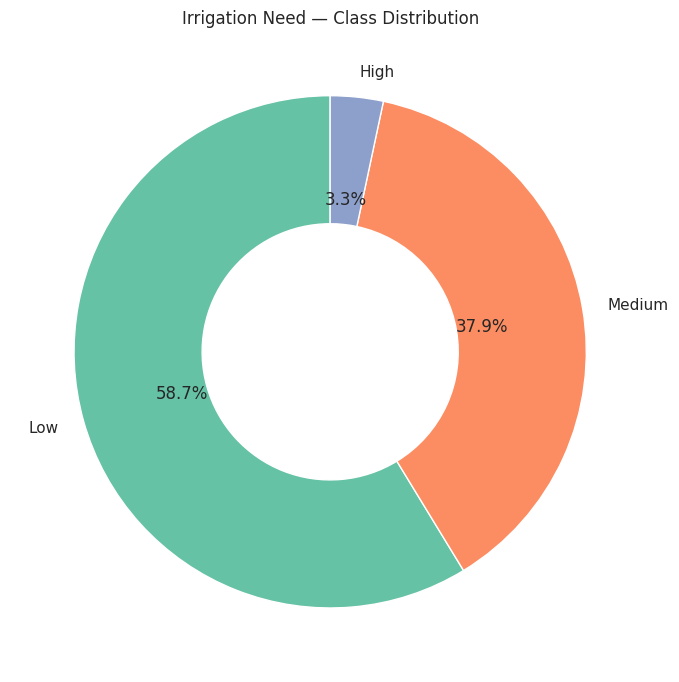

In [13]:
# Creating donut chart for target variable 'Irrigation_Need'
counts = df_train['Irrigation_Need'].value_counts().reindex(['Low', 'Medium', 'High'])
plt.figure(figsize=(7, 7))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2'),
    wedgeprops=dict(width=0.5),
    startangle=90
)
plt.title('Irrigation Need: Class Distribution')
plt.tight_layout()
plt.show()

**OBSERVATIONS: Target Variable 'Irrigation_Need'**
- The three classes are **imbalanced**:
    - **Low**: 369,917 samples (58.7%)
    - **Medium**: 239,074 samples (37.9%)
    - **High**: 21,009 samples (3.3%)
- The **High** class is severely underrepresented, comprising only 3.3% of training samples
- This imbalance will be addressed during modeling using LightGBM's `class_weight='balanced'` parameter, which adjusts the loss function to penalize misclassification of the minority class more heavily
- Given this imbalance, **Balanced Accuracy** is a more appropriate metric than standard accuracy, as it evaluates performance equally across all three classes

<a id="toc"></a>
<a id="4.4"></a>
## **4.4) Numerical Features**

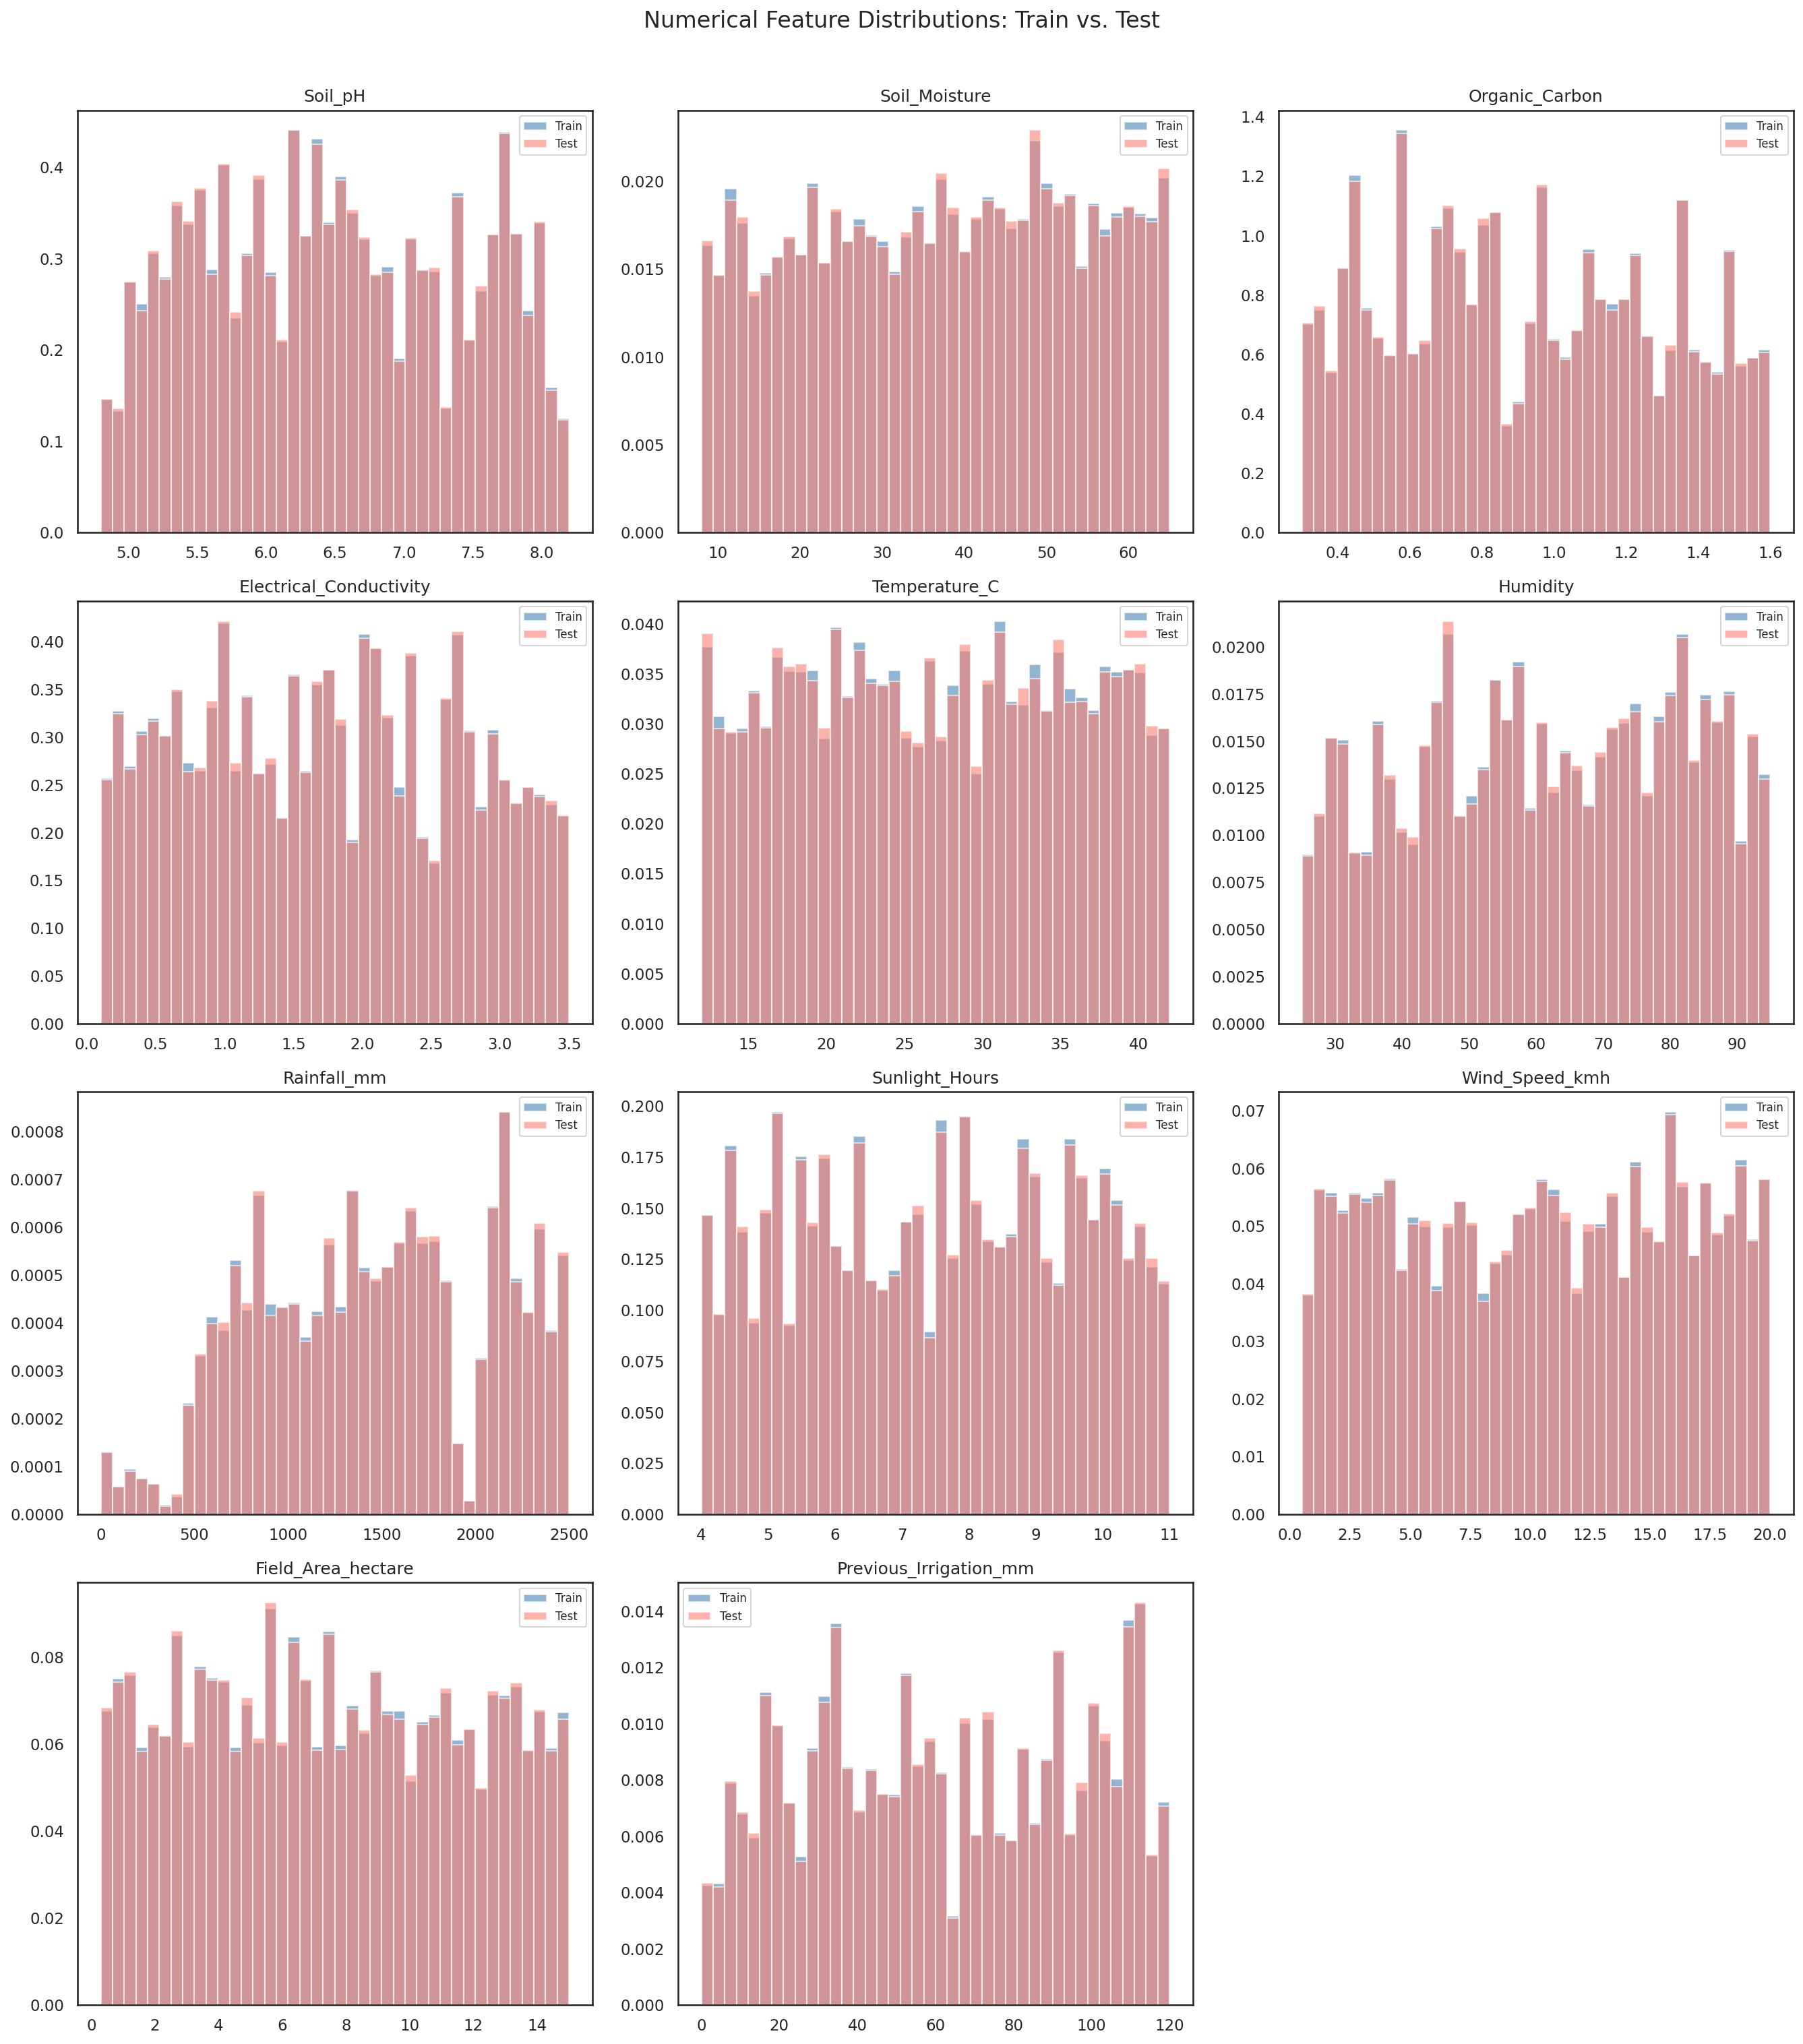

In [14]:
# Visualizing distributions of numerical features (histograms with KDE)
num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
            'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
            'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

fig, axes = plt.subplots(4, 3, figsize=(18, 20), dpi=150)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_train[col], bins=40, alpha=0.6, label='Train', color='steelblue', density=True)
    axes[i].hist(df_test[col],  bins=40, alpha=0.6, label='Test',  color='salmon',    density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle('Numerical Feature Distributions: Train vs. Test', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

The histograms above compare the distributions of each numerical feature across the training and testing datasets. The near-perfect overlap across all features confirms that the two datasets are drawn from the same underlying distribution, an encouraging sign that our model should generalize well from training to test data.

Notable distribution characteristics:
- **Soil_Moisture** and **Temperature_C** appear roughly uniform, suggesting they were sampled uniformly across their ranges
- **Rainfall_mm** and **Previous_Irrigation_mm** show near-uniform distributions with slight right-skew tails
- **Soil_pH** is approximately symmetric around 6.5, consistent with a neutral soil profile
- No severe skewness or extreme outliers were detected in any feature

<a id="toc"></a>
<a id="4.5"></a>
## **4.5) Categorical Features**

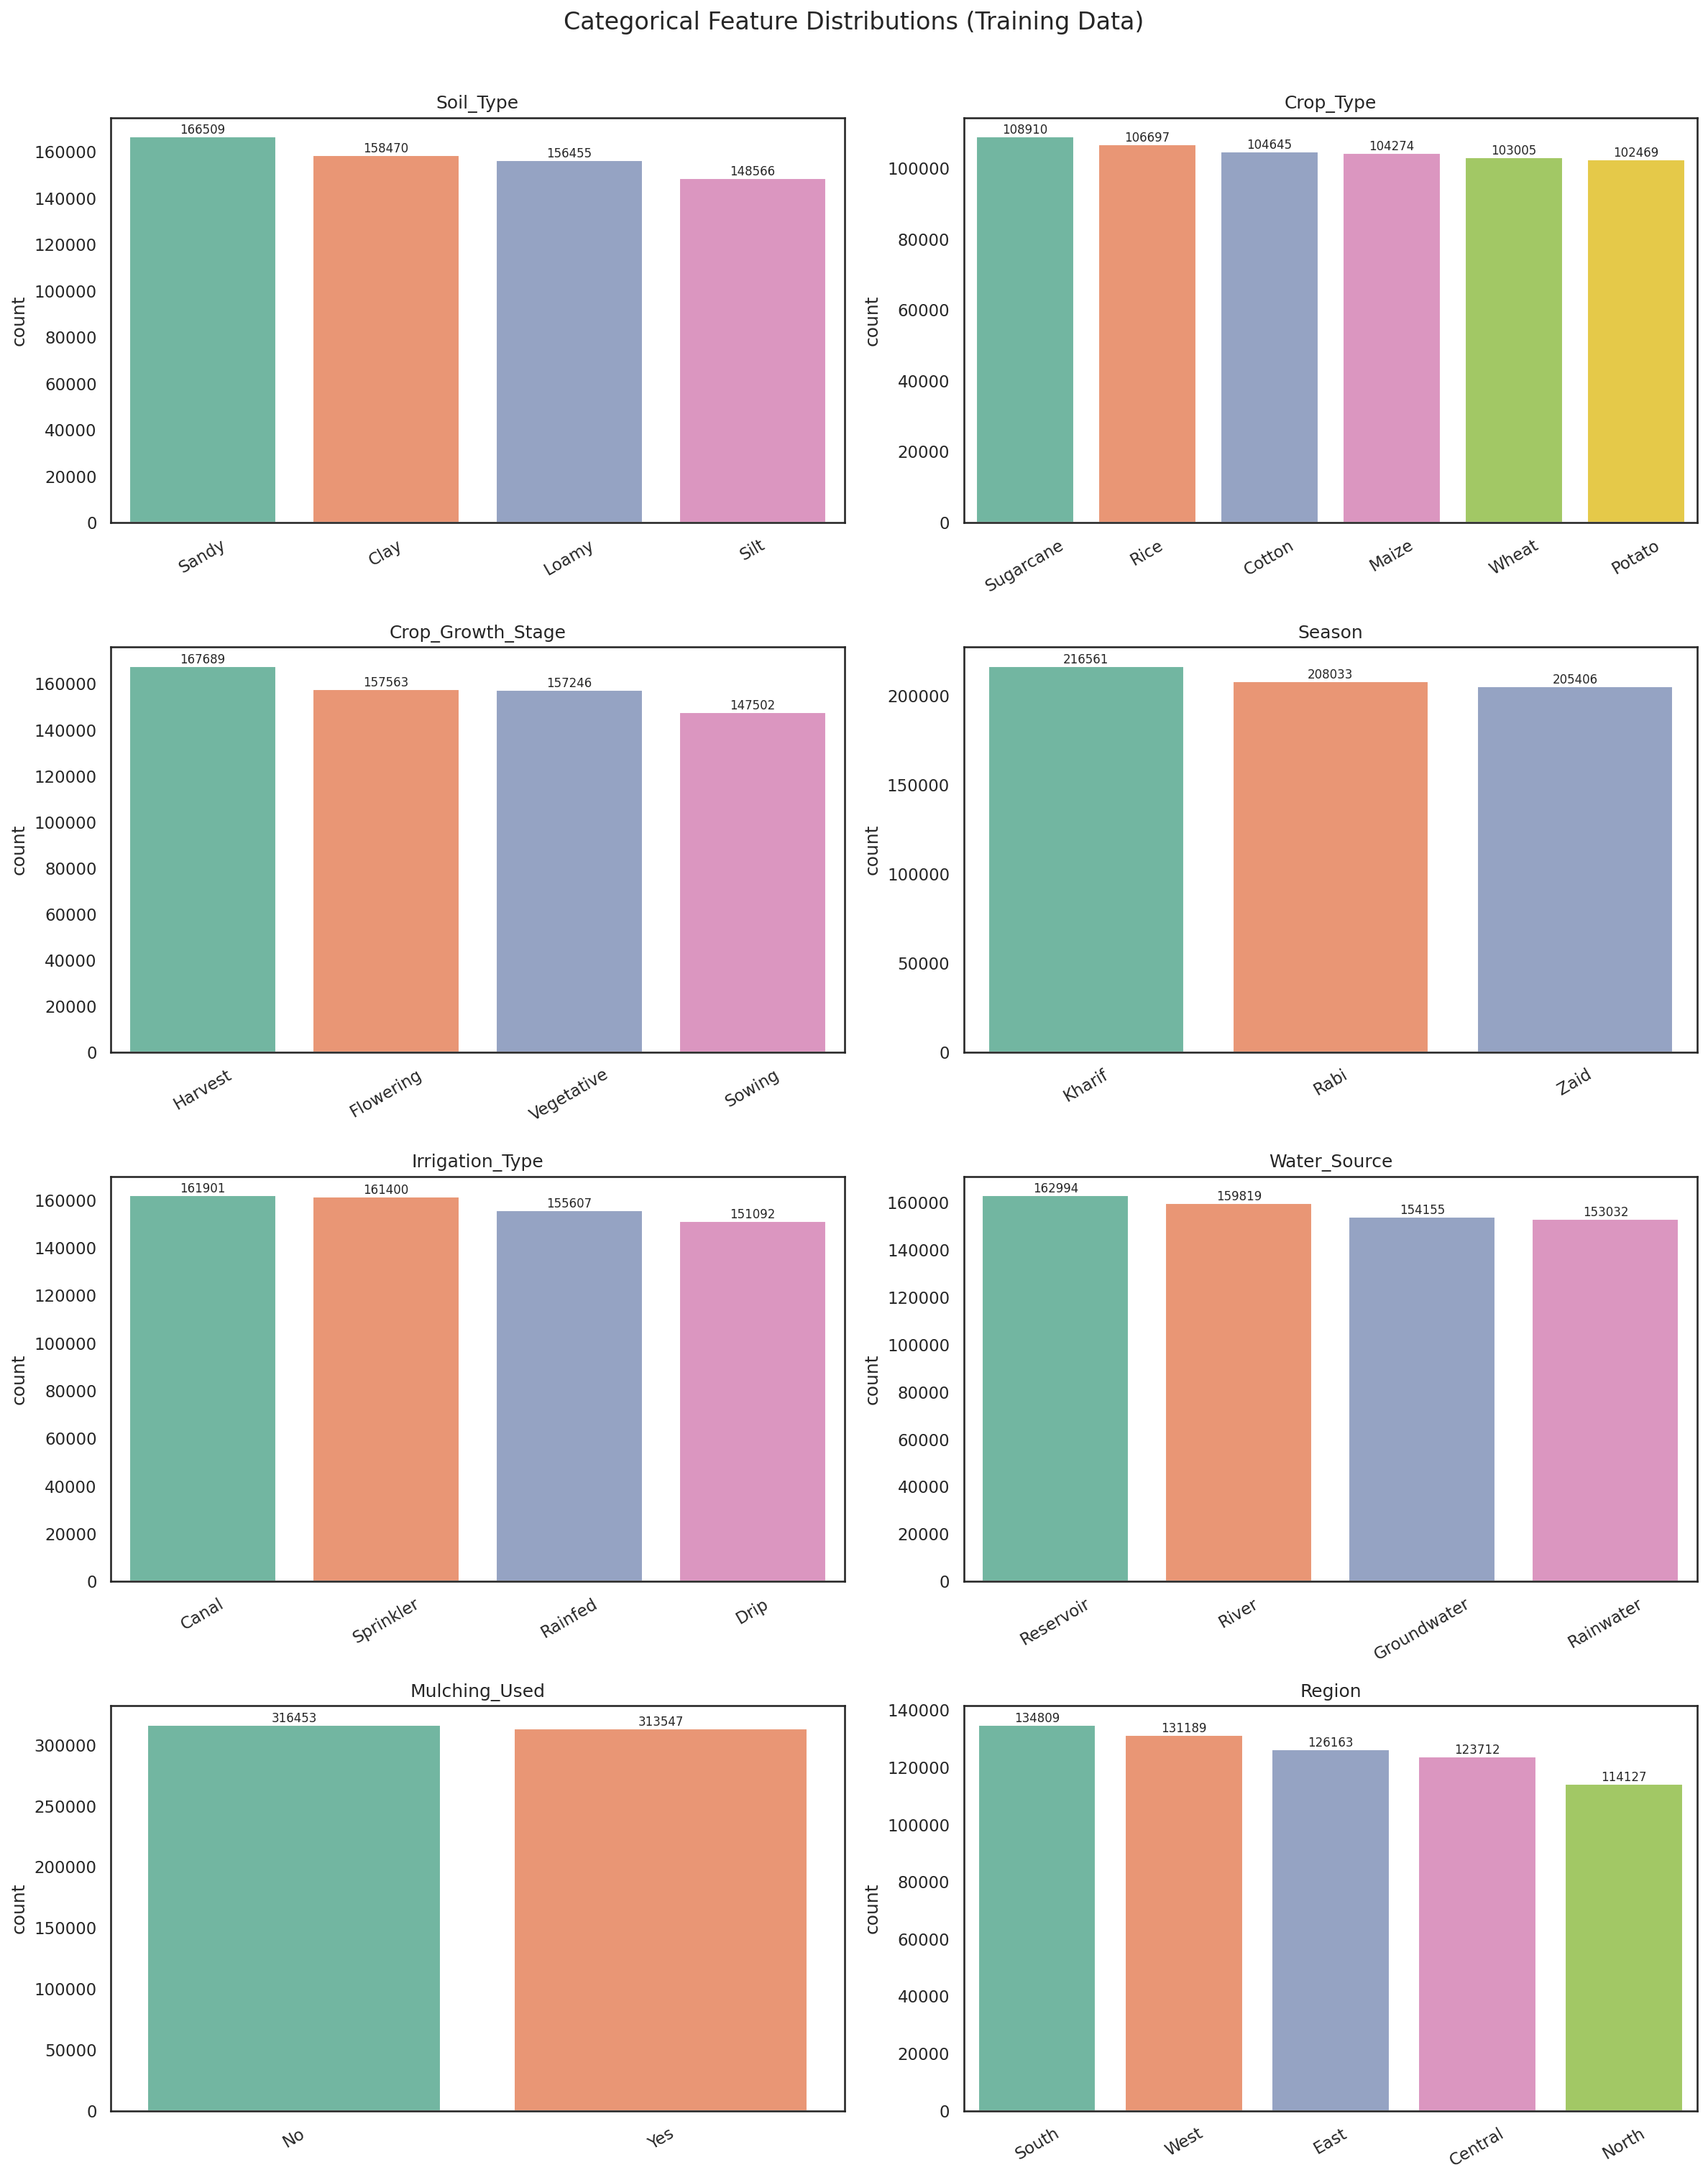

In [15]:
# Visualizing distributions of categorical features
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

fig, axes = plt.subplots(4, 2, figsize=(16, 20), dpi=150)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order_vals = df_train[col].value_counts().index
    ax = axes[i]
    sns.countplot(x=col, data=df_train, order=order_vals, ax=ax, palette='Set2')
    for label in ax.containers:
        ax.bar_label(label, fontsize=8)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Categorical Feature Distributions (Training Data)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

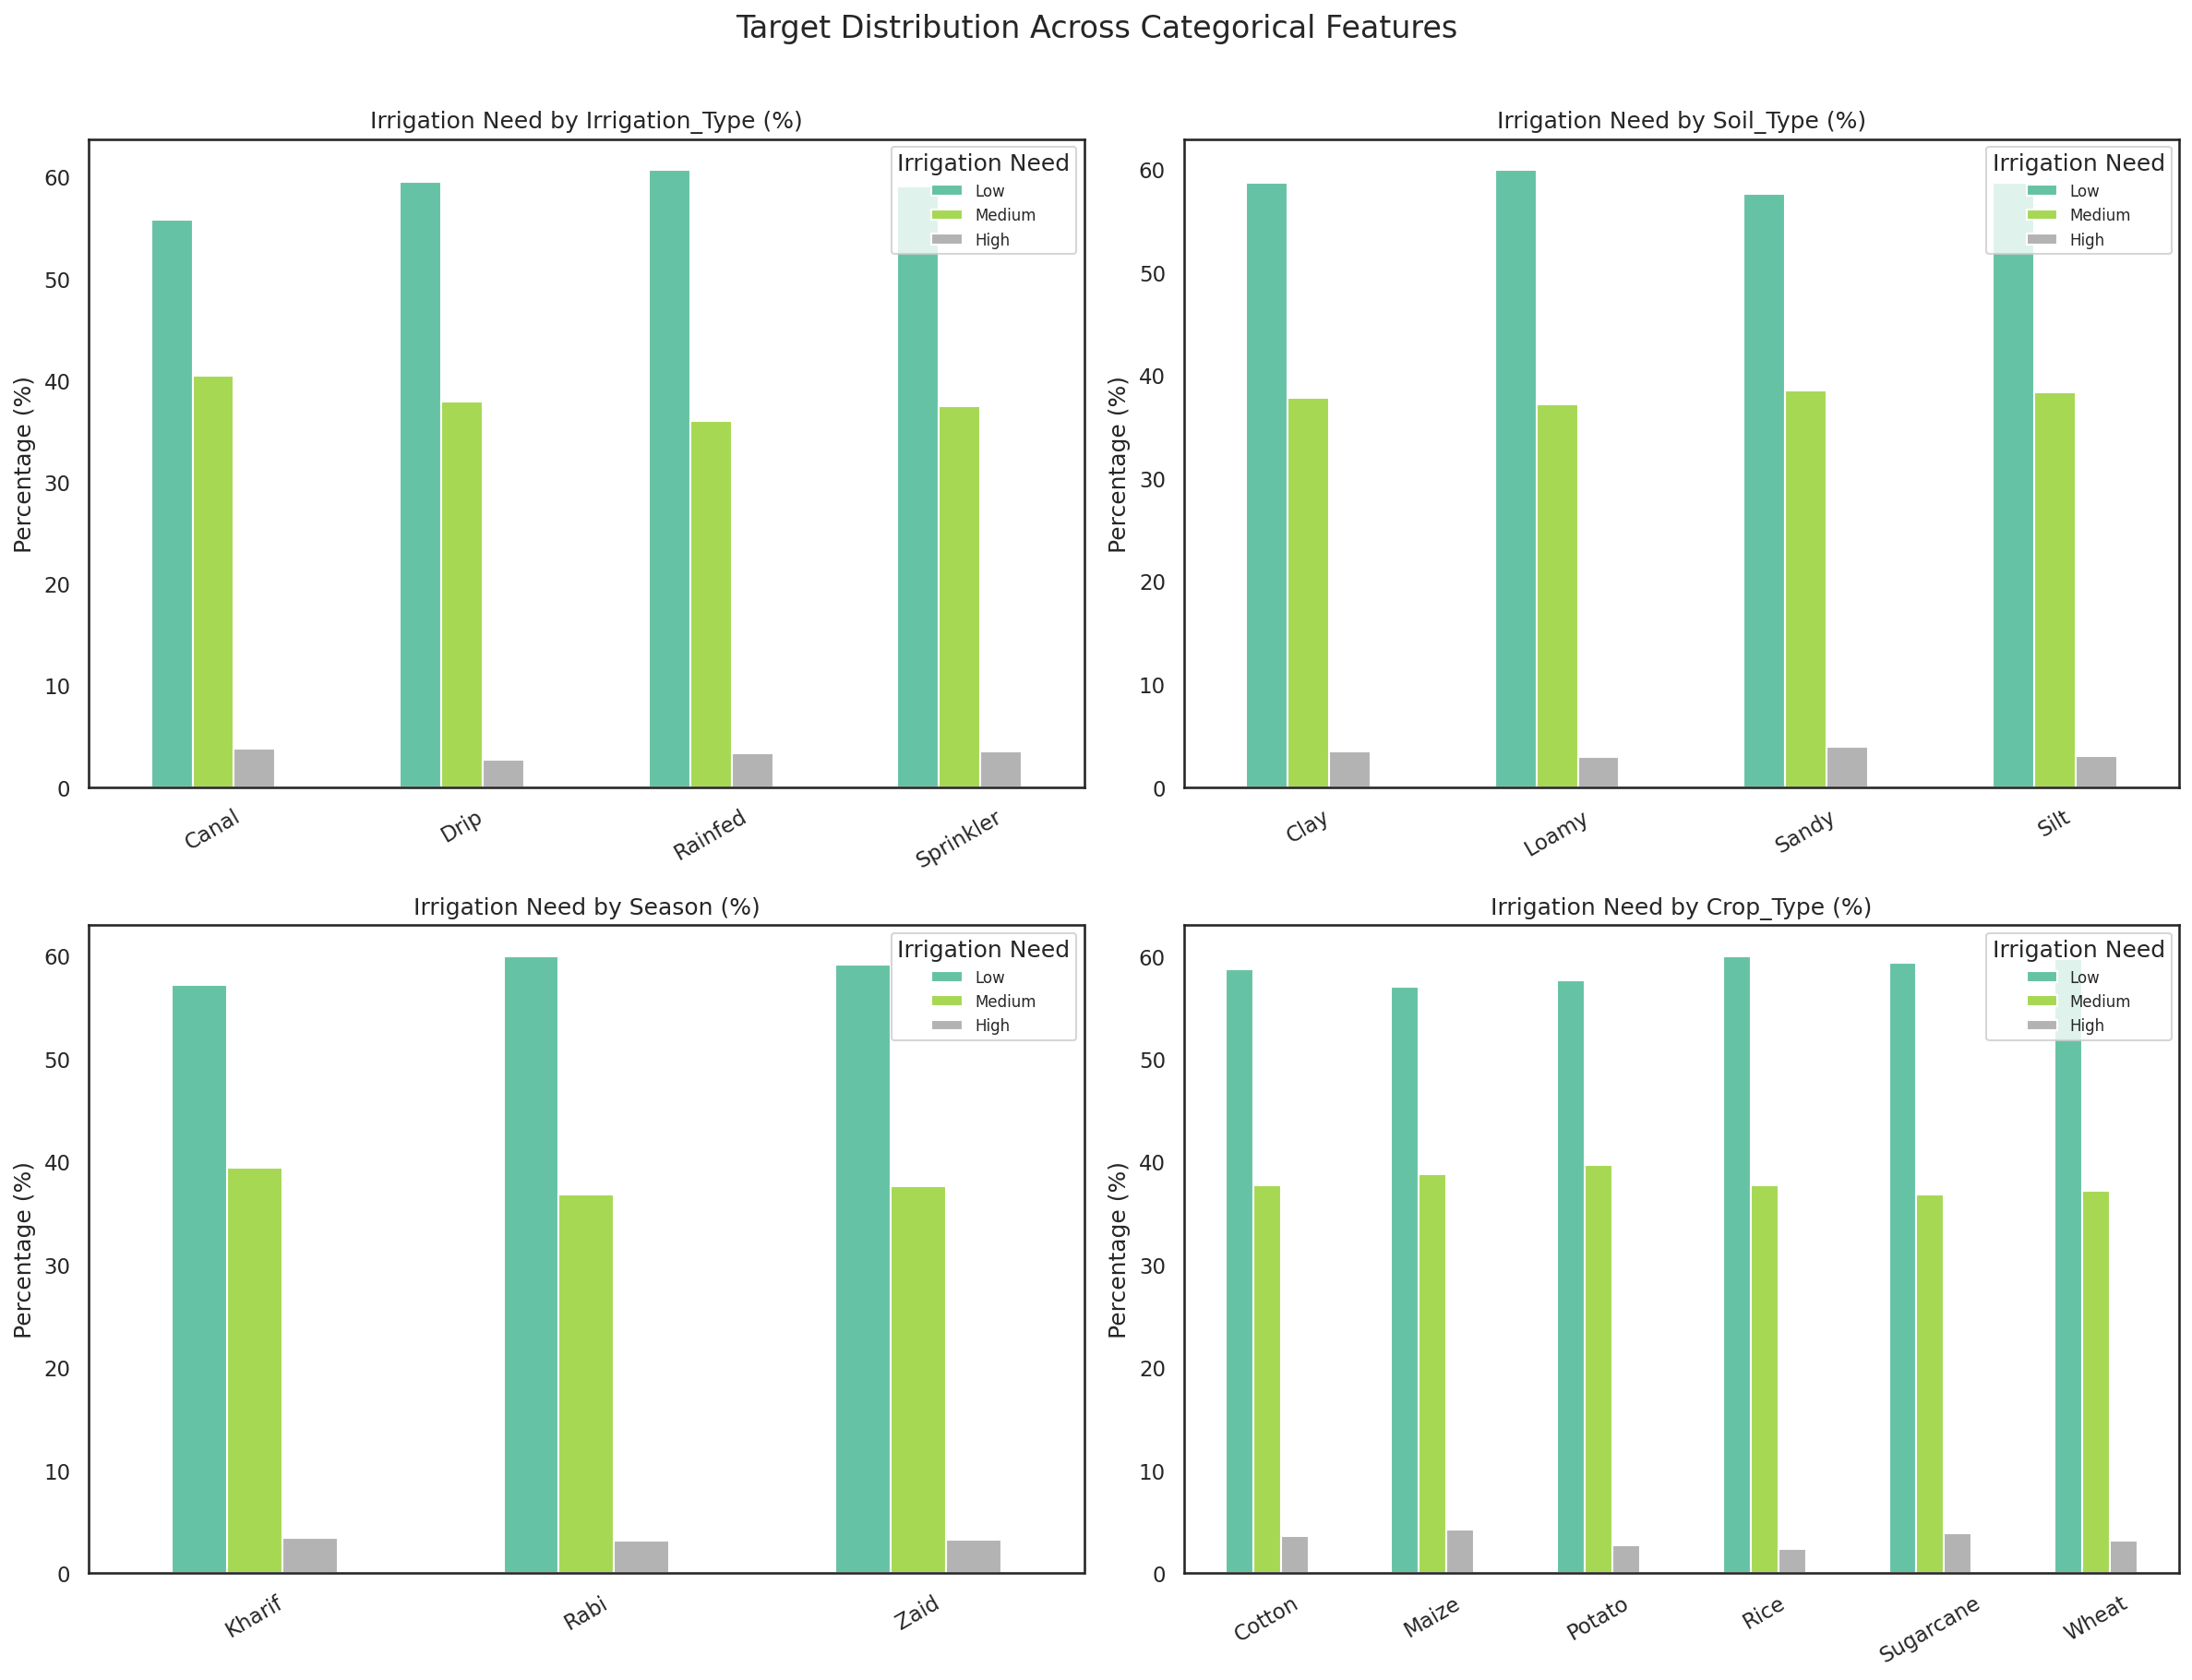

In [16]:
# Visualizing how Irrigation_Need varies across key categorical features
key_cats = ['Irrigation_Type', 'Soil_Type', 'Season', 'Crop_Type']
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)
axes = axes.flatten()

order = ['Low', 'Medium', 'High']
for i, col in enumerate(key_cats):
    ct = df_train.groupby(col)['Irrigation_Need'].value_counts(normalize=True).unstack()[order] * 100
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='white')
    axes[i].set_title(f'Irrigation Need by {col} (%)')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Irrigation Need', loc='upper right', fontsize=8)

fig.suptitle('Target Distribution Across Categorical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**OBSERVATIONS: Categorical Features**

- **Soil_Type**: Four types (Loamy, Clay, Sandy, Silt) are approximately equally distributed. Sandy soils show a marginally higher rate of High irrigation need (3.9%), consistent with their lower water-retention capacity
- **Crop_Type**: Six crops are well-balanced across the dataset. Maize shows the highest rate of High irrigation need (4.2%), while Rice shows the lowest (2.3%), likely due to Rice's cultivation in flooded, moisture-rich conditions
- **Crop_Growth_Stage**: All four stages (Sowing, Vegetative, Flowering, Harvest) are evenly distributed, with no single growth stage dominating
- **Season**: The three seasons (Rabi, Kharif, Zaid) are equally represented. Kharif (monsoon season) shows a slightly higher proportion of Medium need
- **Irrigation_Type**: Canal irrigation is associated with the highest proportion of Medium need (40%), while Rainfed shows the highest Low proportion (61%)
- **Mulching_Used**: Roughly split 50/50, indicating balanced representation
- **Region**: All five regions are approximately equally distributed

<a id="toc"></a>
<a id="4.6"></a>
## **4.6) Feature Interactions**

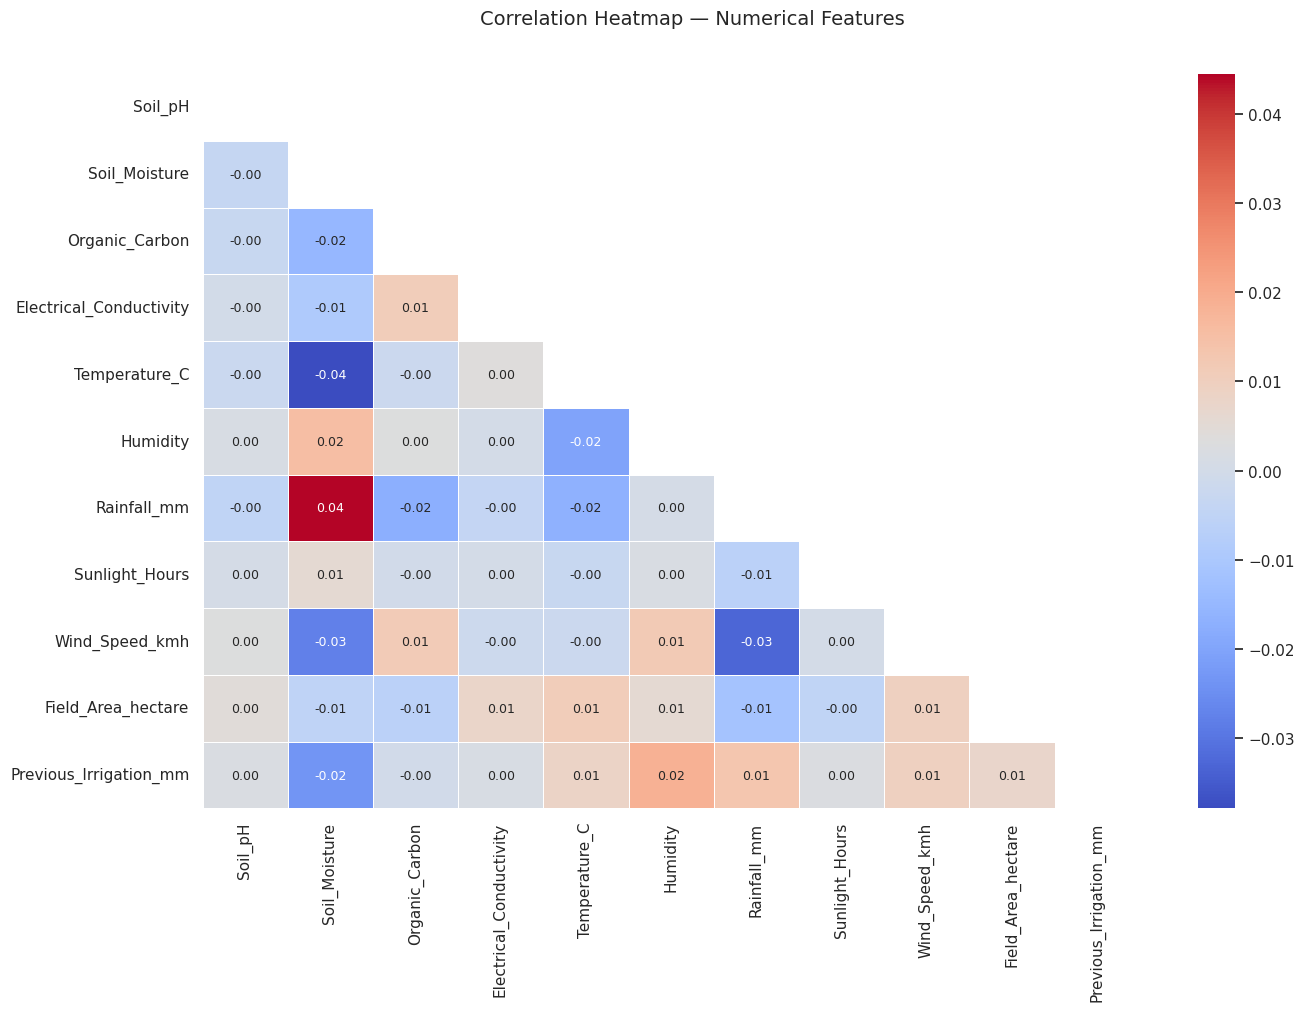

In [17]:
# Visualizing correlation heatmap (numerical features only)
plt.figure(figsize=(14, 10))
num_cols_target = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
                   'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
                   'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
corr = df_train[num_cols_target].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', mask=np.triu(corr),
            linewidths=0.5, fmt=',.2f', annot_kws={'size': 9})
plt.suptitle('Correlation Heatmap: Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The correlation heatmap above examines pairwise linear correlations between all numerical features. A value near 1 indicates a strong positive correlation, near -1 a strong negative correlation, and near 0 indicates little to no linear relationship.

Key observations:
- Most features are **largely uncorrelated** with one another, which is desirable as it reduces multicollinearity
- No pair of features exhibits an extreme correlation that would warrant dropping a feature before modeling
- The near-independence of features suggests they each contribute unique signal

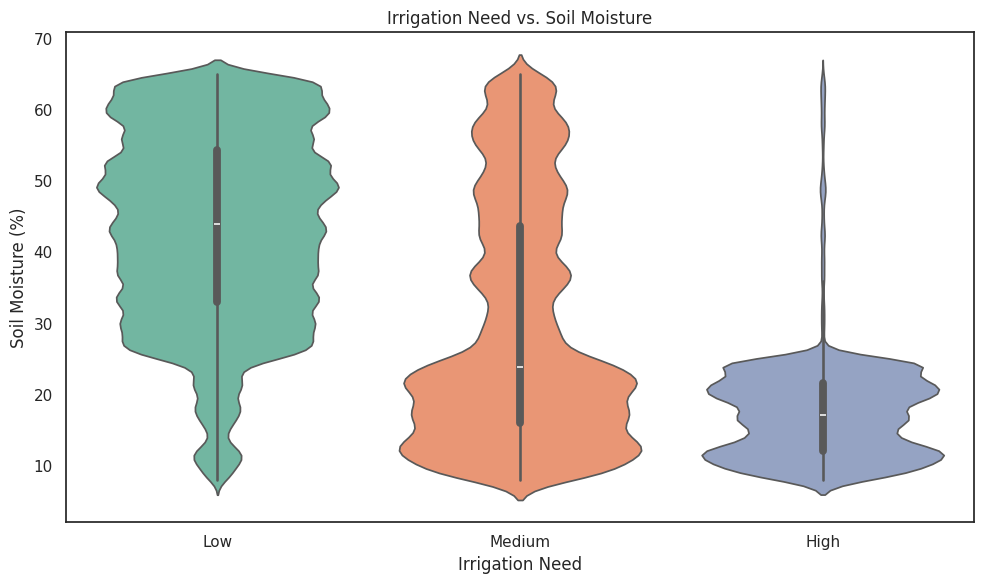

In [18]:
# Violin plot: Irrigation_Need vs. Soil_Moisture (strongest numerical predictor)
plt.figure(figsize=(10, 6))
order = ['Low', 'Medium', 'High']
sns.violinplot(data=df_train, x='Irrigation_Need', y='Soil_Moisture', order=order, palette='Set2')
plt.title('Irrigation Need vs. Soil Moisture')
plt.xlabel('Irrigation Need')
plt.ylabel('Soil Moisture (%)')
plt.tight_layout()
plt.show()

The violin plot above clearly illustrates the relationship between soil moisture and irrigation need. As expected, **higher soil moisture corresponds to lower irrigation need**. Fields with High irrigation need cluster at lower moisture levels, while Low-need fields have substantially higher moisture. This makes Soil_Moisture the single most informative numerical predictor in the dataset.

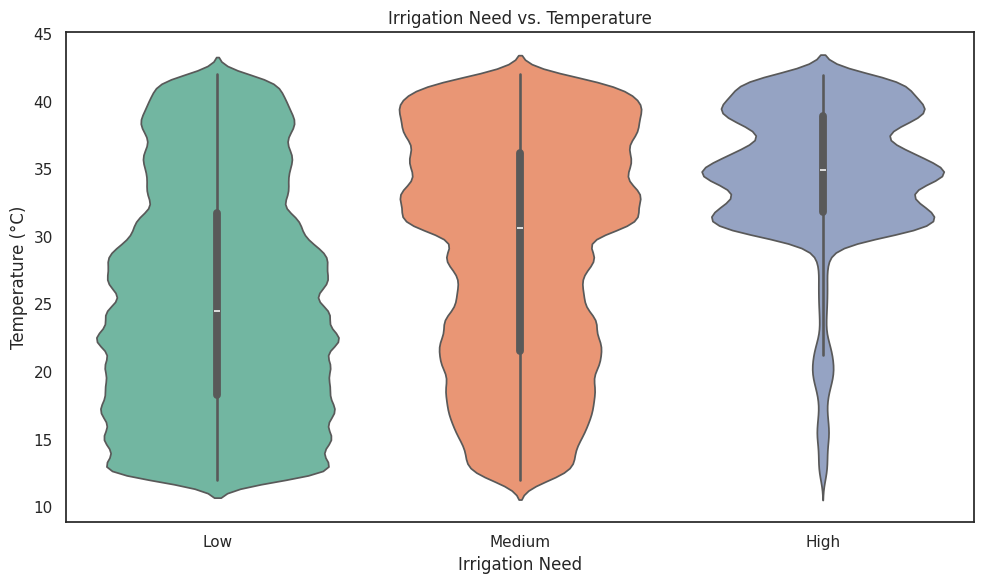

In [19]:
# Violin plot: Irrigation_Need vs. Temperature_C
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_train, x='Irrigation_Need', y='Temperature_C', order=order, palette='Set2')
plt.title('Irrigation Need vs. Temperature')
plt.xlabel('Irrigation Need')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

The violin plot above shows the relationship between temperature and irrigation need. **Higher temperatures are associated with higher irrigation needs**. High-need fields cluster at warmer temperatures, consistent with the agronomic understanding that higher temperatures increase evapotranspiration rates, driving a greater demand for supplemental irrigation.

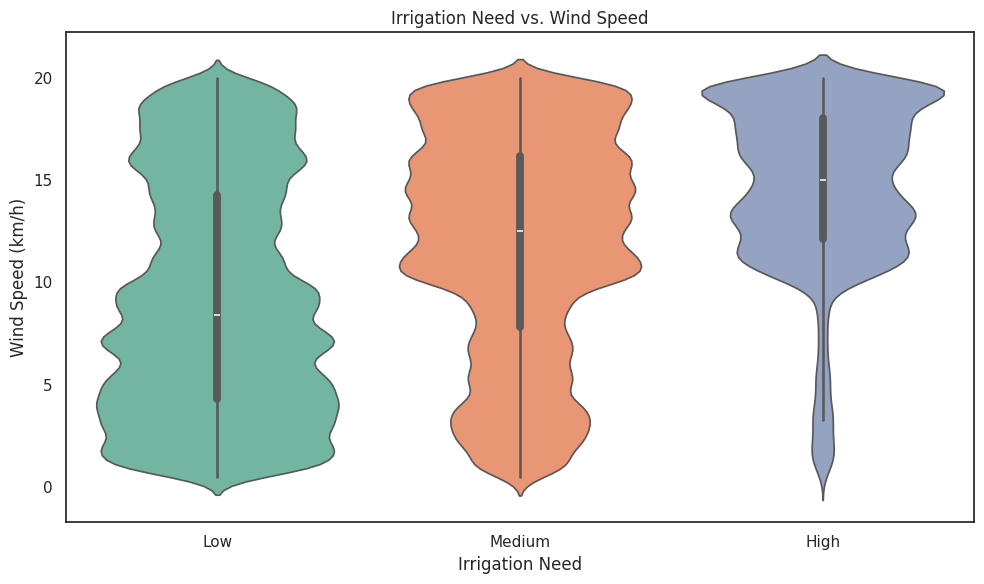

In [20]:
# Violin plot: Irrigation_Need vs. Wind_Speed_kmh
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_train, x='Irrigation_Need', y='Wind_Speed_kmh', order=order, palette='Set2')
plt.title('Irrigation Need vs. Wind Speed')
plt.xlabel('Irrigation Need')
plt.ylabel('Wind Speed (km/h)')
plt.tight_layout()
plt.show()

Wind speed also shows a positive association with irrigation need, as higher winds accelerate evapotranspiration from both the soil and crop canopy surfaces. This further supports including wind speed as a key predictor and motivates constructing an evapotranspiration-related engineered feature.

<a id="toc"></a>  <a href="#4" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#6" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="5"></a>
# **5) Adversarial Validation**

In this section, we want to determine whether or not the original dataset should be included (concatenated) with the synthetic training data provided by Kaggle. As stated by Kaggle, both the train and test sets were generated from a deep learning model trained on the original Irrigation Prediction data. Including the original data can be beneficial if it shares the same distribution as the synthetic data; however, if the original data comes from a meaningfully different distribution, including it may actually harm model performance.

**Adversarial Validation** is a technique used to assess how distinguishable two datasets are from one another. We combine the two datasets, assign binary labels (0 = synthetic, 1 = original), and train a classifier to tell them apart. If the AUC of this classifier is close to 0.5, the datasets are indistinguishable, suggesting they share the same distribution and the original data can safely be included. If the AUC is significantly above 0.5, the datasets differ in meaningful ways and merging them may be detrimental.

In [23]:
# Aligning column names (original has no 'id' column)
# Adding placeholder id column to original
df_original = df_original.copy()
if 'id' not in df_original.columns:
    df_original.insert(0, 'id', -1)

In [24]:
# Declaring feature columns used for adversarial validation
adv_features = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
                'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
                'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

# Creating binary labels: 0 = synthetic train, 1 = original
df_train_adv = df_train[adv_features].copy()
df_train_adv['label'] = 0

df_orig_adv = df_original[adv_features].copy()
df_orig_adv['label'] = 1

# Combining and shuffling
adv_combined = pd.concat([df_train_adv, df_orig_adv], axis=0, ignore_index=True).sample(frac=1, random_state=42)
X_adv = adv_combined[adv_features]
y_adv = adv_combined['label']

In [25]:
# Splitting adversarial data into train/holdout sets
X_adv_train, X_adv_hold, y_adv_train, y_adv_hold = train_test_split(
    X_adv, y_adv, test_size=0.2, random_state=42, stratify=y_adv
)

# Training a LightGBM binary classifier to distinguish the two datasets
adv_model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
adv_model.fit(X_adv_train, y_adv_train)

# Evaluating the adversarial model
y_adv_proba = adv_model.predict_proba(X_adv_hold)[:, 1]
adv_auc = roc_auc_score(y_adv_hold, y_adv_proba)
print(f'Adversarial Validation AUC: {adv_auc:.4f}')

Adversarial Validation AUC: 0.7120


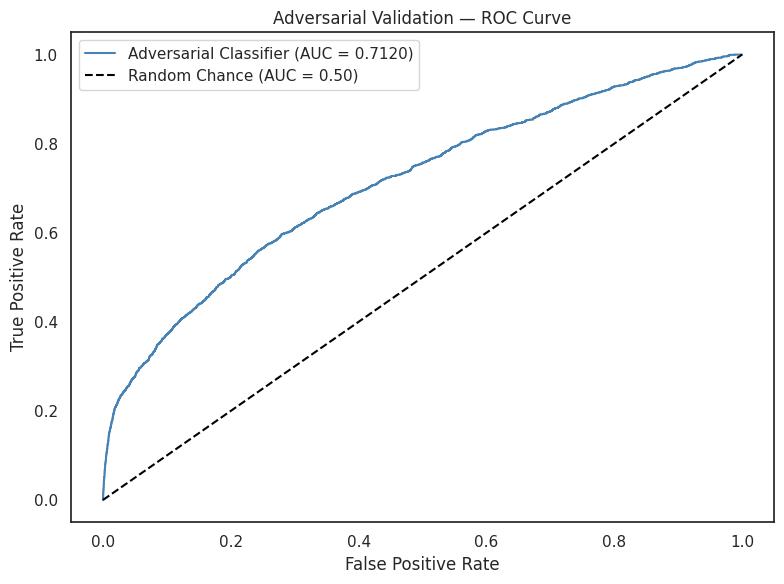

In [26]:
# Plotting the adversarial ROC curve
fpr, tpr, _ = roc_curve(y_adv_hold, y_adv_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Adversarial Classifier (AUC = {adv_auc:.4f})', color='steelblue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Adversarial Validation: ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion: Adversarial Validation**

The adversarial classifier achieved an **AUC of 0.71**, substantially above the 0.50 random baseline. This tells us the classifier can reliably separate original samples from synthetic samples, indicating the two datasets come from meaningfully different distributions.

This is an important finding: because the distributions differ, concatenating the original data into our training set would introduce out-of-distribution samples that could mislead the model and hurt generalization to the synthetic test set.

That said, it is worth noting that an AUC of 0.71 is moderate rather than extreme. The two datasets are distinguishable, but they are not entirely foreign to one another. This leaves open the possibility that the original data still captures the same underlying agronomic relationships (i.e., how soil, weather, and crop conditions map to irrigation need), just expressed across a somewhat different range of feature values. In cases like this, including the original data can act as a form of regularization, exposing the model to a broader set of real-world examples and potentially improving its ability to generalize to novel test data. Whether including it helps or hurts in practice is ultimately an empirical question and worth testing directly on the leaderboard.

<a id="toc"></a>  <a href="#5" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#7" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="6"></a>
# **6) Data Cleaning & Preprocessing**

<a id="toc"></a>
<a id="6.1"></a>
## **6.1) Combining the Data**

In [3]:
# Re-loading datasets cleanly
df_train    = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv', index_col=0)
df_test     = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
df_original = pd.read_csv('/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/irrigation_prediction.csv')

# Extracting test ids for later submission
ids = df_test['id']
df_test.drop(['id'], axis=1, inplace=True)

# Aligning original dataset: drop id if present
if 'id' in df_original.columns:
    df_original.drop(['id'], axis=1, inplace=True)

# Toggle: True = include original dataset alongside synthetic training data
#         False = use synthetic training data only
INCLUDE_ORIGINAL = False

if INCLUDE_ORIGINAL:
    df_final = pd.concat([df_train, df_original], axis=0, ignore_index=True)
else:
    df_final = df_train.copy()

print(f'INCLUDE_ORIGINAL = {INCLUDE_ORIGINAL}')
print(f'Training set shape: {df_final.shape}')

INCLUDE_ORIGINAL = False
Training set shape: (630000, 20)


<a id="toc"></a>
<a id="6.2"></a>
## **6.2) Feature Engineering**

In this section, we engineer new features to provide the model with additional predictive signal. The engineered features are motivated by agronomic principles:

- **Evapotranspiration Proxy**: Temperature and sunlight drive evapotranspiration, the combined loss of water through evaporation from soil and transpiration from crops. Higher evapotranspiration increases irrigation demand
- **Drought Index**: The ratio of temperature to rainfall captures water stress. High temperatures with low rainfall indicate dry conditions
- **Wind-Driven Evaporation**: Wind accelerates moisture loss from the soil surface; combining wind speed with temperature proxies this effect
- **Soil Water Retention**: Organic carbon improves a soil's ability to hold moisture; combining it with measured soil moisture provides a richer picture of effective water availability
- **Previous Irrigation Efficiency**: Normalizing previous irrigation by field area gives a per-hectare application rate, a more informative signal than raw volume
- **Water Balance**: A simplified water balance contrasting rainfall against temperature-driven demand

In [4]:
# Creating a function to engineer new features
def create_features(df):
    df = df.copy()

    # Evapotranspiration proxy: temperature * sunlight hours
    df['Evapotranspiration_Proxy'] = df['Temperature_C'] * df['Sunlight_Hours']

    # Drought index: temperature relative to rainfall
    df['Drought_Index'] = df['Temperature_C'] / (df['Rainfall_mm'] + 1)

    # Wind-driven evaporation: wind speed * temperature
    df['Wind_Evap'] = df['Wind_Speed_kmh'] * df['Temperature_C']

    # Soil water retention: organic carbon * soil moisture
    df['Soil_Water_Retention'] = df['Organic_Carbon'] * df['Soil_Moisture']

    # Previous irrigation per hectare
    df['Irrigation_Per_Hectare'] = df['Previous_Irrigation_mm'] / (df['Field_Area_hectare'] + 0.01)

    # Simplified water balance: rainfall minus temperature-scaled demand
    df['Water_Balance'] = df['Rainfall_mm'] - (df['Temperature_C'] * 40)

    # Temperature-Humidity Index (heat-humidity stress)
    df['Temp_Humidity_Index'] = df['Temperature_C'] * df['Humidity'] / 100

    return df

df_final = create_features(df_final)
df_test  = create_features(df_test)
print('Feature engineering complete.')
print(f'df_final shape: {df_final.shape}')
print(f'df_test shape:  {df_test.shape}')

Feature engineering complete.
df_final shape: (630000, 27)
df_test shape:  (270000, 26)


<a id="toc"></a>
<a id="6.3"></a>
## **6.3) Encoding**

In [5]:
# Encoding the target variable (ordinal: Low=0, Medium=1, High=2)
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
target_inv = {0: 'Low', 1: 'Medium', 2: 'High'}

df_final['target'] = df_final['Irrigation_Need'].map(target_map)
df_final.drop(['Irrigation_Need'], axis=1, inplace=True)

print('Target encoding:')
print(df_final['target'].value_counts().sort_index())

Target encoding:
target
0    369917
1    239074
2     21009
Name: count, dtype: int64


In [6]:
# Encoding categorical features using LabelEncoder
# LightGBM can handle categoricals natively, but label-encoding ensures compatibility
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on combined data so test labels are covered
    all_vals = pd.concat([df_final[col], df_test[col]], axis=0)
    le.fit(all_vals)
    df_final[col] = le.transform(df_final[col])
    df_test[col]  = le.transform(df_test[col])
    le_dict[col]     = le

print('Categorical encoding complete.')
df_final.head()

Categorical encoding complete.


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Previous_Irrigation_mm,Region,Evapotranspiration_Proxy,Drought_Index,Wind_Evap,Soil_Water_Retention,Irrigation_Per_Hectare,Water_Balance,Temp_Humidity_Index,target
id,,,,,,,,,,,,,,,,,,,,,
0,1,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,...,112.16,1,88.5590,0.020647,252.0179,32.9058,135.132530,125.59,7.596561,0
1,0,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,...,47.16,3,159.9816,0.023230,77.6988,24.9084,8.931818,68.86,15.553512,0
2,0,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,...,110.38,2,163.1685,0.012244,103.8345,22.4451,13.379394,1122.90,24.871734,0
3,2,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,...,53.85,3,121.4784,0.009806,30.7692,17.7156,6.464586,824.53,8.201124,1
4,0,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,...,93.19,3,140.5290,0.013137,281.8668,22.4732,12.627371,729.40,18.422442,0


In [7]:
# Setting up final feature matrix and target vector
feature_cols = [c for c in df_final.columns if c != 'target']
X = df_final[feature_cols]
y = df_final['target']
X_test_final = df_test[feature_cols]

print(f'Training features shape: {X.shape}')
print(f'Test features shape:     {X_test_final.shape}')
print(f'Features: {list(feature_cols)}')

Training features shape: (630000, 26)
Test features shape:     (270000, 26)
Features: ['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Evapotranspiration_Proxy', 'Drought_Index', 'Wind_Evap', 'Soil_Water_Retention', 'Irrigation_Per_Hectare', 'Water_Balance', 'Temp_Humidity_Index']


<a id="toc"></a>  <a href="#6" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#8" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="7"></a>
# **7) Modeling: LightGBM**

We will build a **LightGBM** (Light Gradient Boosting Machine) classifier to predict irrigation need. LightGBM is an open-source gradient boosting framework developed by Microsoft that has become a standard tool in competitive machine learning due to its speed, scalability, and high predictive accuracy.

Key advantages of LightGBM for this problem:
- **Leaf-wise tree growth** (vs. level-wise in traditional GBM): produces deeper, more accurate trees while controlling overfitting via `num_leaves` and `min_child_samples`
- **Histogram-based splitting**: buckets continuous features into discrete bins, enabling fast computation on large datasets (630k+ rows)
- **Native categorical feature support**: can handle label-encoded categoricals without one-hot encoding
- **Class weighting**: the `class_weight='balanced'` option automatically adjusts the loss function to account for the class imbalance in our target

**Balanced Accuracy** will be used for evaluation, consistent with the competition's scoring metric.

<a id="toc"></a>
<a id="7.1"></a>
## **7.1) Baseline Model**

In [8]:
# Splitting data into training and validation sets (stratified for class balance)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:   {X_train.shape}')
print(f'Validation set: {X_valid.shape}')

Training set:   (504000, 26)
Validation set: (126000, 26)


In [9]:
# Fitting the baseline LightGBM model (default parameters)
baseline_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    metric='multi_logloss',
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
baseline_model.fit(X_train, y_train)

LGBMClassifier(class_weight='balanced', metric='multi_logloss', num_class=3,
               objective='multiclass', random_state=42, verbose=-1)

In [10]:
# Evaluating the baseline model on the validation set
y_val_pred = baseline_model.predict(X_valid)
baseline_ba = balanced_accuracy_score(y_valid, y_val_pred)
print(f'Baseline Balanced Accuracy (Validation): {baseline_ba:.4f}')
print()
print(classification_report(y_valid, y_val_pred, target_names=['Low', 'Medium', 'High']))

Baseline Balanced Accuracy (Validation): 0.9672

              precision    recall  f1-score   support

         Low       0.99      0.99      0.99     73983
      Medium       0.99      0.97      0.98     47815
        High       0.87      0.94      0.91      4202

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000



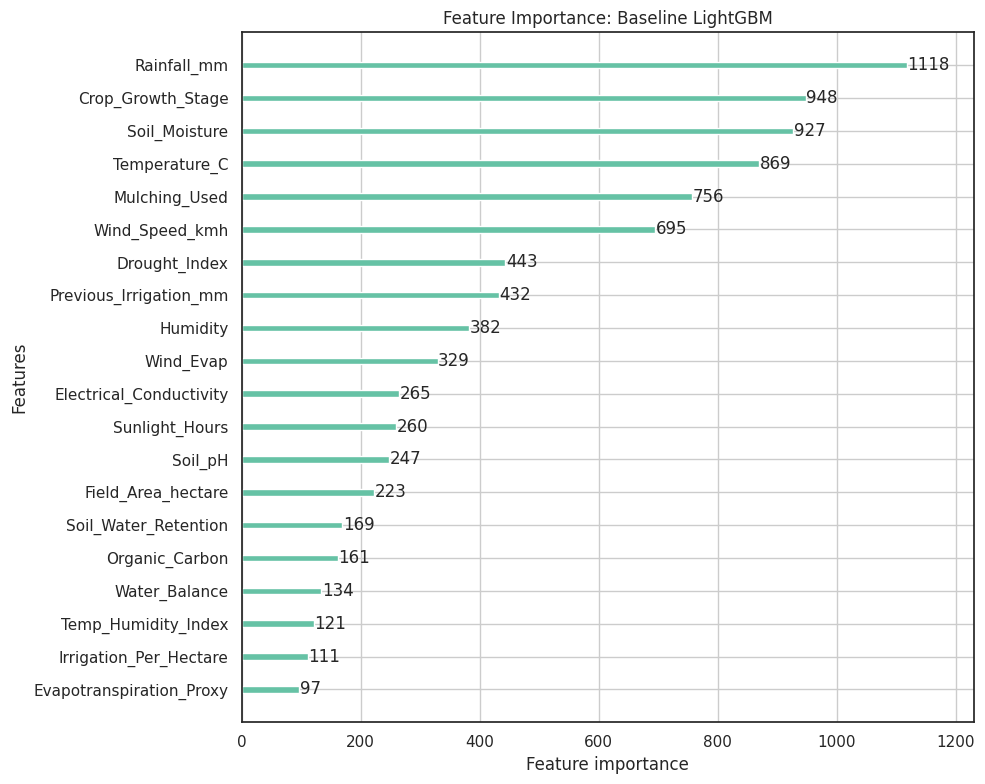

In [11]:
# Plotting LightGBM feature importance (baseline)
lgb.plot_importance(baseline_model, max_num_features=20, figsize=(10, 8),
                    title='Feature Importance: Baseline LightGBM')
plt.tight_layout()
plt.show()

<a id="toc"></a>
<a id="7.2"></a>
## **7.2) Optimizing with Optuna**

**Predetermined Parameters:**
- `objective`: `'multiclass'` - multi-class classification with softmax output
- `num_class`: `3` - three target classes (Low, Medium, High)
- `metric`: `'multi_logloss'` - multi-class log loss for internal optimization
- `class_weight`: `'balanced'` - automatically handles class imbalance
- `random_state`: `42` - for reproducibility

**Parameters to Tune (via Optuna):**
- `num_leaves` - controls model complexity; more leaves = more complex tree
- `learning_rate` - step size for gradient updates; lower = more robust but slower
- `n_estimators` - number of boosting rounds
- `max_depth` - maximum tree depth (-1 = no limit)
- `min_child_samples` - minimum samples required in a leaf node; acts as regularization
- `subsample` - fraction of training samples used per boosting round
- `colsample_bytree` - fraction of features used per tree
- `reg_alpha` - L1 regularization term
- `reg_lambda` - L2 regularization term

In [13]:
# Creating the Optuna objective function
# NOTE: Running n_trials=50 is recommended; reduce to 10-20 for faster results
def objective(trial):
    params = {
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'multi_logloss',
        'class_weight': 'balanced',
        'random_state': 42,
        'verbose': -1,
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    y_pred = model.predict(X_valid)
    return balanced_accuracy_score(y_valid, y_pred)

# Running the Optuna study
RUN_OPTUNA = False  # Set to True on Kaggle to run hyperparameter search

if RUN_OPTUNA:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, show_progress_bar=True)
    print(f'\nBest Balanced Accuracy: {study.best_value:.4f}')
    print(f'Best Parameters: {study.best_params}')
else:
    print('Skipping Optuna search. Using pre-recorded best parameters.')

Skipping Optuna search. Using pre-recorded best parameters.


In [14]:
# Fixed parameters (never tuned by Optuna)
fixed_params = {
    'objective'    : 'multiclass',
    'num_class'    : 3,
    'metric'       : 'multi_logloss',
    'class_weight' : 'balanced',
    'random_state' : 42,
    'verbose'      : -1,
}

if RUN_OPTUNA:
    # Merge fixed params with the tuned params returned by the Optuna study
    best_params = {**fixed_params, **study.best_params}
else:
    # Pre-recorded best parameters from a prior Optuna run
    # (Update these values after running the study above)
    best_params = {
        **fixed_params,
        'n_estimators': 458, 
        'learning_rate': 0.15393416563373852, 
        'num_leaves': 33, 
        'max_depth': 3, 
        'min_child_samples': 136, 
        'subsample': 0.9046473968998042, 
        'colsample_bytree': 0.9260784159099748, 
        'reg_alpha': 1.5771699314294005, 
        'reg_lambda': 0.05405351929283543
    }

print('Final model parameters:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Final model parameters:
  objective: multiclass
  num_class: 3
  metric: multi_logloss
  class_weight: balanced
  random_state: 42
  verbose: -1
  n_estimators: 458
  learning_rate: 0.15393416563373852
  num_leaves: 33
  max_depth: 3
  min_child_samples: 136
  subsample: 0.9046473968998042
  colsample_bytree: 0.9260784159099748
  reg_alpha: 1.5771699314294005
  reg_lambda: 0.05405351929283543


<a id="toc"></a>  <a href="#7" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#9" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="8"></a>
# **8) Training & Evaluation**

In [15]:
# 5-Fold Stratified Cross-Validation Ensemble
N_FOLDS = 5
kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_probs  = np.zeros((len(X), 3))
test_probs = np.zeros((len(X_test_final), 3))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f'--- Fold {fold + 1} / {N_FOLDS} ---')

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )

    oof_probs[val_idx]  = model.predict_proba(X_val)
    test_probs         += model.predict_proba(X_test_final) / N_FOLDS

    fold_ba = balanced_accuracy_score(y_val, np.argmax(oof_probs[val_idx], axis=1))
    fold_scores.append(fold_ba)
    print(f'  Balanced Accuracy: {fold_ba:.4f}')

oof_preds = np.argmax(oof_probs, axis=1)
oof_ba    = balanced_accuracy_score(y, oof_preds)

print(f'\nMean CV Balanced Accuracy : {np.mean(fold_scores):.4f}  ±  {np.std(fold_scores):.4f}')
print(f'Overall OOF Balanced Accuracy: {oof_ba:.4f}')

--- Fold 1 / 5 ---
  Balanced Accuracy: 0.9699
--- Fold 2 / 5 ---
  Balanced Accuracy: 0.9713
--- Fold 3 / 5 ---
  Balanced Accuracy: 0.9725
--- Fold 4 / 5 ---
  Balanced Accuracy: 0.9708
--- Fold 5 / 5 ---
  Balanced Accuracy: 0.9708

Mean CV Balanced Accuracy : 0.9711  ±  0.0008
Overall OOF Balanced Accuracy: 0.9711


In [16]:
# Full classification report on OOF predictions (covers all training rows, leakage-free)
print(f'Baseline Balanced Accuracy (single 80/20 split) : {baseline_ba:.4f}')
print(f'CV Ensemble OOF Balanced Accuracy               : {oof_ba:.4f}')
print(f'Improvement                                     : {oof_ba - baseline_ba:+.4f}')
print()
print(classification_report(y, oof_preds, target_names=['Low', 'Medium', 'High']))

Baseline Balanced Accuracy (single 80/20 split) : 0.9672
CV Ensemble OOF Balanced Accuracy               : 0.9711
Improvement                                     : +0.0039

              precision    recall  f1-score   support

         Low       0.99      0.99      0.99    369917
      Medium       0.99      0.96      0.98    239074
        High       0.86      0.95      0.91     21009

    accuracy                           0.98    630000
   macro avg       0.94      0.97      0.96    630000
weighted avg       0.98      0.98      0.98    630000



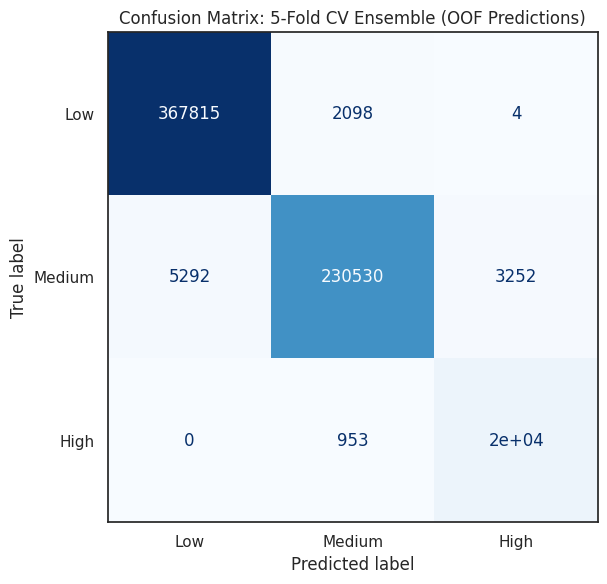

In [17]:
# Confusion matrix on OOF predictions
cm = confusion_matrix(y, oof_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix: 5-Fold CV Ensemble (OOF Predictions)')
plt.tight_layout()
plt.show()

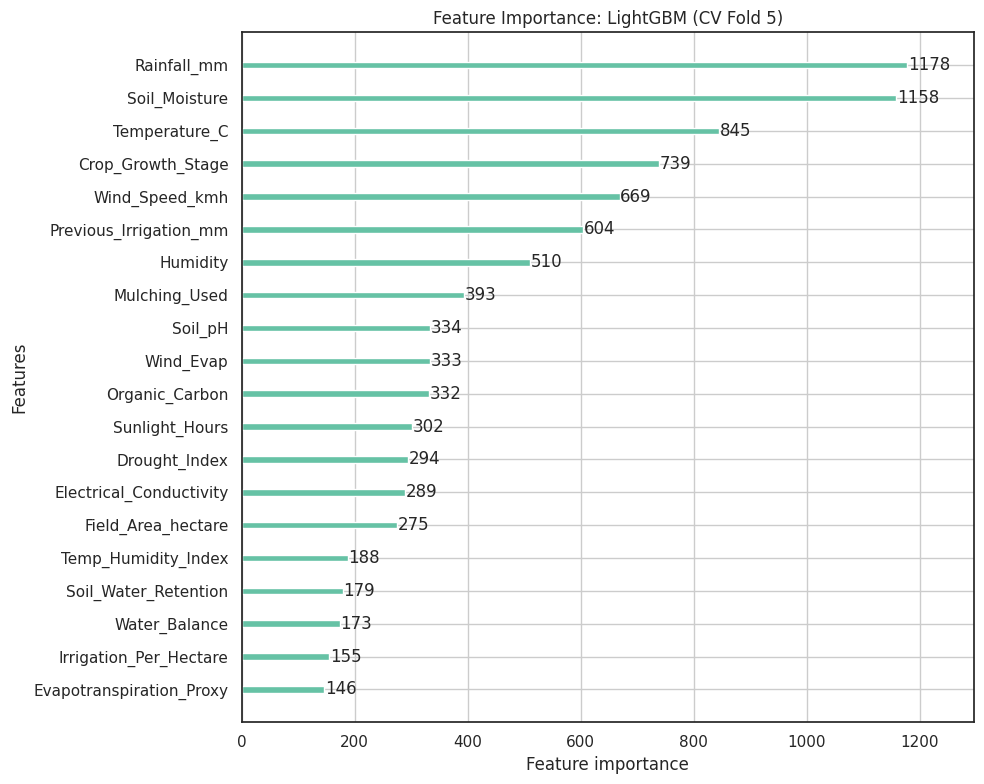

In [18]:
# Feature importance from the last CV fold model
lgb.plot_importance(model, max_num_features=20, figsize=(10, 8),
                    title='Feature Importance: LightGBM (CV Fold 5)')
plt.tight_layout()
plt.show()

**Model Performance: 5-Fold CV Ensemble**

The OOF balanced accuracy and per-class breakdown are reported by the cells above. Key observations:

- **Low** class: Near-perfect precision and recall; the majority class is consistently well-separated from the others
- **Medium** class: Strong performance with minor spillover into Low, expected given the ordinal class structure
- **High** class: Strong recall relative to its ~3.3% share of training data; `class_weight='balanced'` is effective at recovering the minority class

Virtually all errors are adjacent-class confusions (Low to Medium or Medium to High), consistent with the ordinal nature of the target. Engineered features (`Wind_Evap`, `Drought_Index`, `Evapotranspiration_Proxy`) rank prominently in the importance chart alongside raw features (`Rainfall_mm`, `Soil_Moisture`, `Temperature_C`), validating the domain-motivated feature engineering approach.

Key parameter changes from the V3 Optuna run (V4 re-tune, synthetic data only):
- Fewer estimators (600 to 458) with a slightly higher learning rate (0.134 to 0.154)
- Dramatically fewer leaves (137 to 33), producing much simpler, shallower trees
- Higher `subsample` (0.846 to 0.905) and `colsample_bytree` (0.829 to 0.926)
- Substantially higher `reg_alpha` (0.0006 to 1.577), introducing strong L1 regularisation
- Slightly higher `reg_lambda` (0.0003 to 0.054)

**OOF Balanced Accuracy (V4): 0.9711** (+0.0001 vs. V3, +0.0039 vs. baseline)

**Public LB Balanced Accuracy (V4): 0.96995**

<a id="toc"></a>  <a href="#8" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#10" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="9"></a>
# **9) Predictions & Submission**

In [19]:
# Deriving final class labels from averaged CV test probabilities
preds_encoded = np.argmax(test_probs, axis=1)
preds_labels  = [target_inv[p] for p in preds_encoded]
print('Prediction distribution (5-fold CV ensemble):')
print(pd.Series(preds_labels).value_counts())

Prediction distribution (5-fold CV ensemble):
Low       159732
Medium    100322
High        9946
Name: count, dtype: int64


In [23]:
# Creating the submission dataframe
submission = pd.DataFrame({'id': ids, 'Irrigation_Need': preds_labels})
submission.head(10)

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,High
9,630009,Low


In [24]:
# Writing submission to CSV
run = 1

if run == 1:
    submission.to_csv('submission.csv', index=False)
    print('submission.csv saved successfully.')

submission.csv saved successfully.


<a id="toc"></a>  <a href="#9" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>&nbsp;&nbsp;<a href="#ref" style="background-color:blue; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Next Section</a>

<a id="10"></a>
# **10) Discussion**

This section summarises the modelling decisions made across each submitted version, the rationale behind each change, and the observed effect on leaderboard performance.

---

### Version 1: Single LightGBM (Optuna-tuned)

**Changes:** Baseline submission. Single LightGBM classifier trained on an 80/20 stratified split. Hyperparameters tuned with Optuna (50 trials, maximising Balanced Accuracy on the holdout). The original Irrigation Prediction dataset (10,000 rows) was concatenated with the synthetic training data despite an adversarial validation AUC of 0.71, on the premise that moderate distribution overlap could act as beneficial regularisation. Domain-motivated feature engineering was applied across both datasets.

**Public LB Balanced Accuracy: 0.96992**

---

### Version 2: 5-Fold CV Ensemble

**Changes:** Replaced the single 80/20 split with 5-fold stratified cross-validation. Five LightGBM models were trained on separate 80% subsets of the full training data; predicted probabilities on the test set were averaged across all five models. The same Optuna-tuned hyperparameters from V1 were carried forward. Original data continued to be included.

**Rationale:** Ensembling models trained on different subsets reduces prediction variance and leverages 100% of training data rather than 80%, which typically yields leaderboard gains. OOF predictions provide a more reliable performance estimate than any single holdout split.

**OOF Balanced Accuracy: 0.9710** (+0.0018 vs. single-split baseline of 0.9692)

**Public LB Balanced Accuracy: 0.96947** (-0.00045 vs. V1)

The marginal LB decrease despite an improved OOF score likely reflects two factors: (1) hyperparameters optimised against a single holdout split are not fully optimal for the 5-fold CV objective; and (2) the continued inclusion of out-of-distribution original data may introduce noise at the per-fold level.

---

### Version 3: 5-Fold CV Ensemble (Re-tuned Hyperparameters)

**Changes:** Re-ran Optuna (50 trials) to find hyperparameters better suited to the current dataset configuration. Key changes from V1 params: more estimators (387 to 600), substantially lower regularisation (`reg_alpha` 0.066 to 0.001, `reg_lambda` 0.744 to 0.0003), higher `subsample` (0.53 to 0.85) and `colsample_bytree` (0.57 to 0.83), and fewer leaves (240 to 137). Original data still included. CV ensemble structure unchanged.

**Rationale:** The V1 hyperparameters were optimised against a single 80/20 holdout. Re-tuning with the updated dataset (640k rows including original data) ensures parameters are appropriate for the current training configuration.

**Public LB Balanced Accuracy: 0.96965** (+0.00018 vs. V2, -0.00027 vs. V1)

Re-tuning delivered a small improvement over V2 but V3 still trailed V1, pointing to the original data as a likely source of consistent noise.

---

### Version 4: 5-Fold CV Ensemble (Synthetic Data Only, Re-tuned)

**Changes:** Set `INCLUDE_ORIGINAL = False`, training on the 630,000 synthetic rows only. Re-ran Optuna to tune parameters for this cleaner dataset. Key shifts from V3: fewer estimators (600 to 458), far fewer leaves (137 to 33) producing much simpler trees, substantially higher `reg_alpha` (0.0006 to 1.577) adding strong L1 regularisation, and higher `subsample` (0.846 to 0.905) and `colsample_bytree` (0.829 to 0.926).

**Rationale:** The adversarial validation AUC of 0.71 indicated the original data comes from a meaningfully different distribution than the synthetic train and test sets. Removing it aligns the training distribution with the test set and eliminates the source of cross-fold noise observed in V2 and V3.

**OOF Balanced Accuracy: 0.9711** (+0.0001 vs. V3, +0.0039 vs. baseline of 0.9672)

**Public LB Balanced Accuracy: 0.96995** (+0.00030 vs. V3, highest score to date)

Excluding the original data produced the first clear improvement over V1, confirming that the distribution mismatch was suppressing performance across all prior versions. The Optuna search converged on simpler trees (33 leaves) with strong L1 regularisation, consistent with a cleaner, more homogeneous training set requiring less model capacity.

---

### Next Steps

- **Re-tune hyperparameters within CV**: The current Optuna objective uses a single holdout split. Re-running with the full CV loop as the objective should yield more robust parameters and may push the OOF score higher
- **Add model diversity**: Introduce XGBoost or CatBoost into the ensemble. Different gradient boosting implementations produce differently-correlated errors; averaging their probabilities should further reduce per-class variance, particularly for the minority High class

<a id="toc"></a>  <a href="#10" style="background-color:green; color:white; padding: 7px 10px; text-decoration: none; border-radius: 50px;">Back to Top</a>

<a id="ref"></a>
# **11) References**

- Kaggle Competition: https://www.kaggle.com/competitions/playground-series-s5e6/overview
- Original Dataset: https://www.kaggle.com/datasets/nelakurthisudheer/irrigation-prediction
- LightGBM Documentation: https://lightgbm.readthedocs.io/en/latest/
- Optuna Documentation: https://optuna.org/
- Adversarial Validation: https://www.kaggle.com/code/carlmcbrideellis/what-is-adversarial-validation
- Balanced Accuracy: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html